<a href="https://colab.research.google.com/github/wtryab-re/data-preprocessing/blob/main/Loan_Approval_Dataset_EDA_%26_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install and Import

In [646]:
!pip install -q pandas numpy seaborn matplotlib imblearn scikit-learn fg_data_profiling

In [647]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from data_profiling import ProfileReport

#Helps impute values faster
from sklearn.impute import SimpleImputer

In [648]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', "{:.3f}".format)
sns.set_style("darkgrid")

#Dataframe

In [649]:
df = pd.read_csv("loan.csv")
df.shape

(614, 13)

In [650]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.000,NaN,360.000,1.000,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.000,128.000,360.000,1.000,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.000,66.000,360.000,1.000,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.000,120.000,360.000,1.000,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.000,141.000,360.000,1.000,Urban,Y


#Data EDA

In [651]:
#EDA_Report = ProfileReport(df, title="Loan Approval Profiling Report", )
#EDA_Report.to_file("Loan_Approval_Profiling_Report.html")

#Data Overview

In [652]:
df.shape

(614, 13)

In [653]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [654]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


#DO NOT WORK ON THE ACTUAL DATASET

In [655]:
df_copy = df.copy()

In [656]:
df_copy.shape

(614, 13)

#Basic Cleanup & Data Quality Checks

In [657]:
df_copy.columns = [col.lower() for col in df_copy.columns]
df_copy.columns = [col.replace("_", "") for col in df_copy.columns]
df_copy.columns

Index(['loanid', 'gender', 'married', 'dependents', 'education',
       'selfemployed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loanamountterm', 'credithistory', 'propertyarea', 'loanstatus'],
      dtype='object')

In [658]:
df.nunique()

,0
Loan_ID,614
Gender,2
Married,2
Dependents,4
Education,2
Self_Employed,2
ApplicantIncome,505
CoapplicantIncome,287
LoanAmount,203
Loan_Amount_Term,10


ID-like, Constant and Quasi Constant Columns

In [659]:
id_like_cols = []
constant_cols = []
quasi_constant_cols = []

#constant cols - nunique = 1
#quasiconstant - value_counts max proportion > 90
#id-like - nunique/rows*100 >90

for col in df_copy.columns:
  if df_copy[col].nunique() == 1:
    constant_cols.append(col)
  elif df_copy[col].nunique()/df_copy.shape[0]*100 > 90:
    id_like_cols.append(col)
  elif df_copy[col].value_counts(normalize=True).max()*100 > 90:
    quasi_constant_cols.append(col)

print(f"ID-Like Columns: {id_like_cols}")
print(f"Constant Columns: {constant_cols}")
print(f"Quasi Constant Columns: {quasi_constant_cols}")

drop_cols = id_like_cols + constant_cols + quasi_constant_cols

ID-Like Columns: ['loanid']
Constant Columns: []
Quasi Constant Columns: []


In [660]:
df_copy.drop(drop_cols, inplace = True, axis = 1)
df_copy.shape

(614, 12)

##Missing Values Check

In [661]:
df_copy.isna().sum().sort_values(ascending=False)

,0
credithistory,50
selfemployed,32
loanamount,22
dependents,15
loanamountterm,14
gender,13
married,3
education,0
coapplicantincome,0
applicantincome,0


In [662]:
df.duplicated().sum()

np.int64(0)

In [663]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


##String Inconsistencies

In [664]:
text_cols = df_copy.select_dtypes(exclude=np.number).columns
df_copy[text_cols] = df_copy[text_cols].apply(lambda x: x.str.strip())
df_copy[text_cols] = df_copy[text_cols].apply(lambda x: x.str.lower())

##High Null Columns

In [665]:
missing_count = df_copy.isna().sum().sort_values(ascending=False)
missing_percentage = (df_copy.isna().mean()*100).sort_values(ascending=False)

missing_df = pd.DataFrame({"missing_count":missing_count,"missing_percentage":missing_percentage})
missing_df[missing_df["missing_count"]>0]

,missing_count,missing_percentage
credithistory,50,8.143
selfemployed,32,5.212
loanamount,22,3.583
dependents,15,2.443
loanamountterm,14,2.280
gender,13,2.117
married,3,0.489


##High Zero Columns

In [666]:
numeric_columns = df_copy.select_dtypes(include=np.number).columns
high_zero_threshold = 40
zero_values = (df_copy[numeric_columns]==0).mean()*100
zero_values.sort_values(ascending=False)

,0
coapplicantincome,44.463
credithistory,14.495
applicantincome,0.000
loanamount,0.000
loanamountterm,0.000


##Check for Missing Target Values

In [667]:
target = "loanstatus"

In [668]:
df_copy[target].isna().sum()

np.int64(0)

##Drop Missing Target Value Data

In [669]:
df_copy.dropna(subset=target)
df_copy[target].isna().sum()

np.int64(0)

#Train Test Split

In [670]:
X = df_copy.drop(target, axis=1)
y = df_copy[target]

In [671]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((491, 11), (123, 11), (491,), (123,))

In [672]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

#Separate Num Cols and Categorical Cols

In [673]:
X_train_processed.head()

,gender,married,dependents,education,selfemployed,applicantincome,coapplicantincome,loanamount,loanamountterm,credithistory,propertyarea
154,male,no,0,graduate,no,3254,0.000,50.000,360.000,1.000,urban
239,male,yes,1,graduate,no,3315,0.000,96.000,360.000,1.000,semiurban
448,male,yes,2,graduate,no,3340,1710.000,150.000,360.000,0.000,rural
471,male,yes,1,not graduate,no,2653,1500.000,113.000,180.000,0.000,rural
273,male,yes,0,graduate,no,2620,2223.000,150.000,360.000,1.000,semiurban


In [674]:
X_train_processed.columns

Index(['gender', 'married', 'dependents', 'education', 'selfemployed',
       'applicantincome', 'coapplicantincome', 'loanamount', 'loanamountterm',
       'credithistory', 'propertyarea'],
      dtype='object')

In [675]:
X_train_processed.nunique()

,0
gender,2
married,2
dependents,4
education,2
selfemployed,2
applicantincome,416
coapplicantincome,232
loanamount,185
loanamountterm,10
credithistory,2


In [676]:
for col in X_train_processed.columns:
  print(col, X_train_processed[col].unique())

gender ['male' 'female' nan]
married ['no' 'yes' nan]
dependents ['0' '1' '2' nan '3+']
education ['graduate' 'not graduate']
selfemployed ['no' 'yes' nan]
applicantincome [ 3254  3315  3340  2653  2620  1875  3000  2383  7441  4583 37719 13650
  2876  3750  2583  6000  4166  7333  4333  4288  4000  4695  2045 10000
  3500  5568  6083  5746  3593  3167  2500  2995  3846  3583  5333  5935
  4400  1916  1000  4167  4133  2014  3189  3095  5000  3463  5726  8333
  3547 14583  5417  4860  5285 14999  5818  6700  3775  2917  2400  3727
  5821  3717  4547  3541  6783  2600  2132  1809  2750  3716  5649  1378
  7740  2213  5800 17500  2378  5391  3497  2275  2609  3667  4755  1820
  7142  6080  3159  4735  9703  5829  6875 20233  3833  3276  3600 16692
  3083  6540  1977  8072  4300  1668  6065  1800 10416  5250  5923  7200
  4554 81000  4350  3237  3466  3902  2787  6383  3166  6050  7250  4095
 63337  2083  5316  2395  3675 13262  2667  2929  1025  2366 39999  2894
  3232  6822  4354  3867 

In [677]:
len(X_train_processed.columns)

11

In [678]:

  # gender - cat unorder
  # married - cat unorder
  # dependents - cat ordinal
  # education - cat unorder
  # credit_history - cat unorder
  # selfemployed - cat unorder
  # propertyarea - cat unorder binary no encoding needed

  # applicantincome = number continuous
  # coapplicantincome = number continuous
  # loanamount - number continuous
  # loanamountterm - number discrete

  #loanstatus - category binary encode

In [679]:
preprocessingaction = {
    "columns": ["gender", "married", "dependents", "education", "credithistory", "selfemployed", "propertyarea", "loanstatus (target)", "applicantincome", "coapplicantincome", "loanamount", "loanamountterm"],
    "datatype": ["category", "category", "category", "category", "category", "category", "category", "category", "number", "number", "number", "number"],
    "type": ["binary", "binary", "ordinal", "binary", "binary", "binary", "nominal", "binary" ,"continuous", "continuous","continuous", "discrete"],
    "action": ["label", "label", "label", "label", "already encoded", "label", "one hot", "label", "scale", "scale", "scale", "scale"]
    }


preprocessing_info = pd.DataFrame(preprocessingaction)
preprocessing_info

,columns,datatype,type,action
0,gender,category,binary,label
1,married,category,binary,label
2,dependents,category,ordinal,label
3,education,category,binary,label
4,credithistory,category,binary,already encoded
5,selfemployed,category,binary,label
6,propertyarea,category,nominal,one hot
7,loanstatus (target),category,binary,label
8,applicantincome,number,continuous,scale
9,coapplicantincome,number,continuous,scale


In [680]:
num_cols = ["applicantincome", "coapplicantincome", "loanamount", "loanamountterm"]
cat_cols = ["gender", "married", "dependents", "education", "credithistory", "selfemployed", "propertyarea"]

In [681]:
num_cols  = X_train_processed.select_dtypes(include=np.number).columns.to_list()
cat_cols = X_train_processed.select_dtypes(exclude=np.number).columns.to_list()

num_cols.remove("credithistory")
cat_cols.append("credithistory")

print("Numerical Columns", num_cols)
print("Categorical Columns", cat_cols)

Numerical Columns ['applicantincome', 'coapplicantincome', 'loanamount', 'loanamountterm']
Categorical Columns ['gender', 'married', 'dependents', 'education', 'selfemployed', 'propertyarea', 'credithistory']


#Handling Missing Values

In [682]:
X_train_handled = X_train_processed.copy()
X_test_handled = X_test_processed.copy()

##Categorical Columns

Impute using MOST FREQUENT - Mode

In [683]:
#Before
X_train_handled[cat_cols].isna().sum()

,0
gender,11
married,3
dependents,8
education,0
selfemployed,27
propertyarea,0
credithistory,43


In [684]:
cat_imputer = SimpleImputer(strategy="most_frequent")

In [685]:
X_train_handled[cat_cols] = cat_imputer.fit_transform(X_train_handled[cat_cols])
X_test_handled[cat_cols] = cat_imputer.transform(X_test_handled[cat_cols])

In [686]:
#after
X_train_handled[cat_cols].isna().sum()

,0
gender,0
married,0
dependents,0
education,0
selfemployed,0
propertyarea,0
credithistory,0


#Numerical Columns

In [687]:
#before
X_train_handled[num_cols].isna().sum()

,0
applicantincome,0
coapplicantincome,0
loanamount,20
loanamountterm,12


In [688]:
num_imputer = SimpleImputer(strategy="median")

In [689]:
X_train_handled[num_cols]= num_imputer.fit_transform(X_train_handled[num_cols])
X_test_handled[num_cols] = num_imputer.transform(X_test_handled[num_cols])

In [690]:
#after
X_train_handled[num_cols].isna().sum()

,0
applicantincome,0
coapplicantincome,0
loanamount,0
loanamountterm,0


#Outlier Detection

In [691]:
X_train_outlier_handled = X_train_handled.copy()
X_test_outlier_handled = X_test_handled.copy()

##1. Boxplots

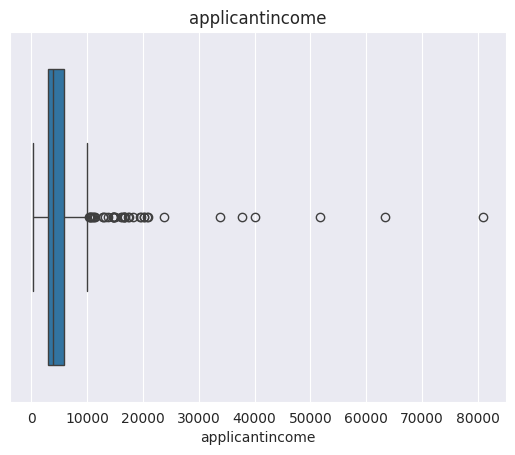

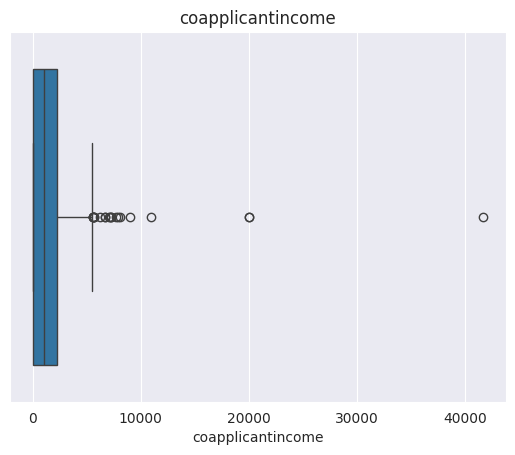

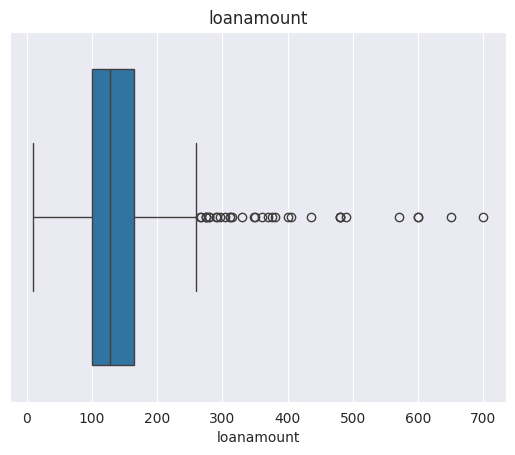

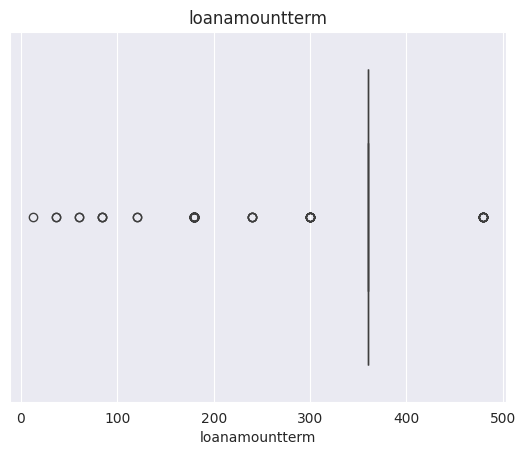

In [692]:
for col in num_cols:
  sns.boxplot(x = X_train_outlier_handled[col])
  plt.title(col)
  plt.show()
  print()

In [693]:
#imo no need to touch loanamountterm it is discrete
#rest can be touched
#yay i was right
num_cols

['applicantincome', 'coapplicantincome', 'loanamount', 'loanamountterm']

In [694]:
desc = {
    "column": num_cols,
    "cap outliers": [1,1,1,0],
    "reason": ["hella outliers","hella outliers","hella outliers", "discrete so no"]
}

pd.DataFrame(desc)


,column,cap outliers,reason
0,applicantincome,1,hella outliers
1,coapplicantincome,1,hella outliers
2,loanamount,1,hella outliers
3,loanamountterm,0,discrete so no


In [695]:
outlier_columns = list( filter(lambda x : x not in ["loanamountterm"], num_cols))
outlier_columns

['applicantincome', 'coapplicantincome', 'loanamount']

###ALWAYS CAP NUMERICAL FEATURES

###DO NOT CAP DISCRETE OR BINARY COLUMNS

###ALWAYS HANDLE MISSING VALUES BEFORE OUTLIERS


##IQR METHOD IS USED FOR NON-NORMAL DISTRIBUTION DATA

##Z-SCORE FOR NORMAL only

#Outlier Handling

In [696]:
def boundary_finder(df, col):
  Q3 = df[col].quantile(0.75)
  Q1 = df[col].quantile(0.25)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR

  return lower_bound, upper_bound

In [697]:
def iqr_method():
  train_boundaries={}
  for col in outlier_columns:
    lower_bound, upper_bound = boundary_finder(X_train_outlier_handled, col)

    X_train_outlier_handled.loc[X_train_outlier_handled[col]<lower_bound, col] = lower_bound
    X_train_outlier_handled.loc[X_train_outlier_handled[col]>upper_bound, col] = upper_bound

    X_test_outlier_handled.loc[X_test_outlier_handled[col]<lower_bound, col] = lower_bound
    X_test_outlier_handled.loc[X_test_outlier_handled[col]>upper_bound, col] = upper_bound

    train_boundaries[col] = [lower_bound, upper_bound]

  return train_boundaries

In [698]:
train_boundaries = iqr_method()
train_boundaries

{'applicantincome': [np.float64(-1472.5), np.float64(10203.5)],
 'coapplicantincome': [np.float64(-3361.5), np.float64(5602.5)],
 'loanamount': [np.float64(3.75), np.float64(261.75)]}

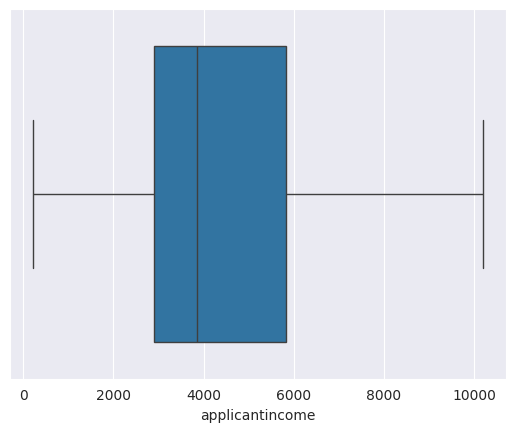

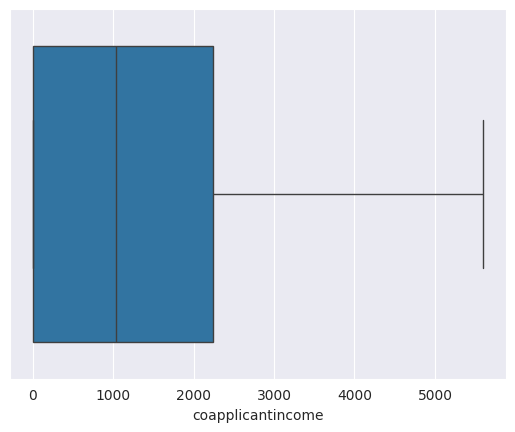

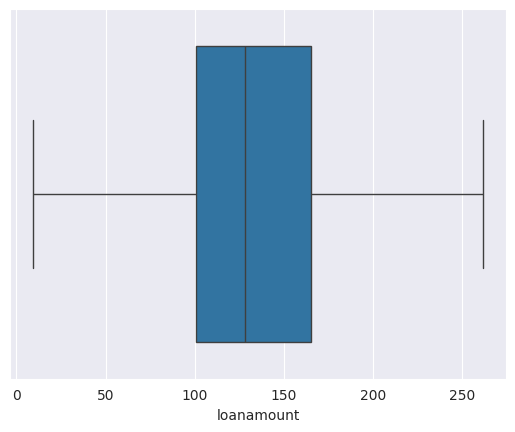

In [699]:
for col in outlier_columns:
  sns.boxplot(x = X_train_outlier_handled[col])
  plt.show()
  print()

#Encoding Categorical Columns

In [700]:
X_train_encoded = X_train_outlier_handled.copy()
X_test_encoded = X_test_outlier_handled.copy()

In [701]:
preprocessing_info

,columns,datatype,type,action
0,gender,category,binary,label
1,married,category,binary,label
2,dependents,category,ordinal,label
3,education,category,binary,label
4,credithistory,category,binary,already encoded
5,selfemployed,category,binary,label
6,propertyarea,category,nominal,one hot
7,loanstatus (target),category,binary,label
8,applicantincome,number,continuous,scale
9,coapplicantincome,number,continuous,scale


##Cat cols grouping

In [702]:
label_columns = preprocessing_info[preprocessing_info["action"]=="label"]["columns"].to_list()
label_columns.remove("loanstatus (target)")
label_columns

['gender', 'married', 'dependents', 'education', 'selfemployed']

In [703]:
one_hot_columns = preprocessing_info[preprocessing_info["action"]=="one hot"]["columns"].to_list()
one_hot_columns

['propertyarea']

##Label Encodings

###1. Encode the target - loanstatus

In [704]:
encoders = {}

In [705]:
le = LabelEncoder()

In [706]:
encoded_y_train = pd.Series(le.fit_transform(y_train), name= target)
encoded_y_test = pd.Series(le.transform(y_test), name=target)
encoders["target"] = le

In [707]:
for col in label_columns:
  X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
  X_test_encoded[col] = le.transform(X_test_encoded[col])
  encoders[col] = le

X_train_encoded.tail()

,gender,married,dependents,education,selfemployed,applicantincome,coapplicantincome,loanamount,loanamountterm,credithistory,propertyarea
222,1,0,0,0,0,2971.000,2791.000,144.000,360.000,1.000,semiurban
349,1,1,0,0,0,2625.000,5602.500,187.000,360.000,1.000,rural
26,1,1,0,0,0,2799.000,2253.000,122.000,360.000,1.000,semiurban
96,0,1,0,0,0,2484.000,2302.000,137.000,360.000,1.000,semiurban
354,0,1,0,0,0,2423.000,505.000,130.000,360.000,1.000,semiurban


In [708]:
encoders

{'target': LabelEncoder(),
 'gender': LabelEncoder(),
 'married': LabelEncoder(),
 'dependents': LabelEncoder(),
 'education': LabelEncoder(),
 'selfemployed': LabelEncoder()}

##One Hot Encoding

In [709]:
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

In [710]:
ohe.fit(X_train_encoded[one_hot_columns])
X_train_ohe_encoded = ohe.transform(X_train_encoded[one_hot_columns])
X_test_ohe_encoded= ohe.transform(X_test_encoded[one_hot_columns])

In [711]:
ohe_col_names = ohe.get_feature_names_out(one_hot_columns)
ohe_col_names

array(['propertyarea_semiurban', 'propertyarea_urban'], dtype=object)

In [712]:
X_train_ohe_encoded = pd.DataFrame(X_train_ohe_encoded, columns=ohe_col_names, index=X_train_encoded.index)
X_test_ohe_encoded = pd.DataFrame(X_test_ohe_encoded, columns=ohe_col_names, index=X_test_encoded.index)

In [713]:
X_train_fully_encoded = pd.concat([X_train_encoded.drop(one_hot_columns, axis=1), X_train_ohe_encoded], axis=1)
X_test_fully_encoded = pd.concat([X_test_encoded.drop(one_hot_columns, axis=1), X_test_ohe_encoded], axis=1)
X_train_fully_encoded.head()

,gender,married,dependents,education,selfemployed,applicantincome,coapplicantincome,loanamount,loanamountterm,credithistory,propertyarea_semiurban,propertyarea_urban
154,1,0,0,0,0,3254.000,0.000,50.000,360.000,1.000,0.000,1.000
239,1,1,1,0,0,3315.000,0.000,96.000,360.000,1.000,1.000,0.000
448,1,1,2,0,0,3340.000,1710.000,150.000,360.000,0.000,0.000,0.000
471,1,1,1,1,0,2653.000,1500.000,113.000,180.000,0.000,0.000,0.000
273,1,1,0,0,0,2620.000,2223.000,150.000,360.000,1.000,1.000,0.000


#Handling Imbalanced Data

Only to be done on training data

In [714]:
encoded_y_train.value_counts()

,count
loanstatus,
1,337
0,154


In [715]:
encoded_y_train.value_counts(normalize = True)

,proportion
loanstatus,
1,0.686
0,0.314


##Oversampling will be used here because dataset small. Can use SMOTE or RandomOversampler

Using SMOTE IN THIS CASE because continuous features.

In [716]:
X_train_resampled, y_train_resampled = SMOTE(random_state=42).fit_resample(X_train_fully_encoded, encoded_y_train)
X_train_resampled.shape, y_train_resampled.shape

((674, 12), (674,))

In [717]:
encoded_y_train

,loanstatus
0,1
1,1
2,0
3,0
4,1
...,...
486,1
487,1
488,1
489,1


#Standardization & Normalization

In [718]:
X_train_standard = X_train_resampled.copy()
X_test_standard = X_test_fully_encoded.copy()

y_train_final = y_train_resampled.copy()
y_test_final = encoded_y_test.copy()

X_train_standard.shape, X_test_standard.shape, y_train_final.shape, y_test_final.shape

((674, 12), (123, 12), (674,), (123,))

In [719]:
num_cols

['applicantincome', 'coapplicantincome', 'loanamount', 'loanamountterm']

In [720]:
scaler = StandardScaler()
scaler.fit(X_train_standard)
X_train_final = pd.DataFrame(scaler.transform(X_train_standard), columns=X_train_standard.columns)
X_test_final = pd.DataFrame(scaler.transform(X_test_standard), columns=X_test_standard.columns)

X_train_final.head()

,gender,married,dependents,education,selfemployed,applicantincome,coapplicantincome,loanamount,loanamountterm,credithistory,propertyarea_semiurban,propertyarea_urban
0,0.505,-1.282,-0.704,-0.477,-0.338,-0.607,-0.853,-1.642,0.270,0.573,-0.778,1.513
1,0.505,0.780,0.353,-0.477,-0.338,-0.582,-0.853,-0.799,0.270,0.573,1.413,-0.731
2,0.505,0.780,1.409,-0.477,-0.338,-0.572,0.216,0.191,0.270,-1.969,-0.778,-0.731
3,0.505,0.780,0.353,2.096,-0.338,-0.855,0.084,-0.487,-2.653,-1.969,-0.778,-0.731
4,0.505,0.780,-0.704,-0.477,-0.338,-0.868,0.536,0.191,0.270,0.573,1.413,-0.731


In [721]:
df_train_processed = pd.concat([X_train_final, y_train_final], axis=1)
df_test_processed = pd.concat([X_test_final, y_test_final], axis=1)

df_train_processed.columns =list( X_train_final.columns )+ [target]
df_test_processed.columns =list( X_train_final.columns )+ [target]

In [722]:
df_train_processed.head()

,gender,married,dependents,education,selfemployed,applicantincome,coapplicantincome,loanamount,loanamountterm,credithistory,propertyarea_semiurban,propertyarea_urban,loanstatus
0,0.505,-1.282,-0.704,-0.477,-0.338,-0.607,-0.853,-1.642,0.270,0.573,-0.778,1.513,1
1,0.505,0.780,0.353,-0.477,-0.338,-0.582,-0.853,-0.799,0.270,0.573,1.413,-0.731,1
2,0.505,0.780,1.409,-0.477,-0.338,-0.572,0.216,0.191,0.270,-1.969,-0.778,-0.731,0
3,0.505,0.780,0.353,2.096,-0.338,-0.855,0.084,-0.487,-2.653,-1.969,-0.778,-0.731,0
4,0.505,0.780,-0.704,-0.477,-0.338,-0.868,0.536,0.191,0.270,0.573,1.413,-0.731,1


In [723]:
df_test_processed.head()

,gender,married,dependents,education,selfemployed,applicantincome,coapplicantincome,loanamount,loanamountterm,credithistory,propertyarea_semiurban,propertyarea_urban,loanstatus
0,0.505,-1.282,-0.704,-0.477,-0.338,0.636,-0.853,-0.396,0.270,-1.969,-0.778,-0.731,0
1,-1.980,0.780,-0.704,-0.477,-0.338,-0.227,0.588,0.777,0.270,0.573,1.413,-0.731,1
2,0.505,0.780,-0.704,-0.477,2.961,2.152,-0.853,0.740,0.270,0.573,-0.778,-0.731,1
3,0.505,0.780,0.353,-0.477,-0.338,0.316,-0.066,0.557,0.270,0.573,-0.778,-0.731,1
4,-1.980,0.780,-0.704,-0.477,-0.338,-0.988,1.950,-0.726,0.270,0.573,1.413,-0.731,1


#SAVE

In [724]:
df_train_processed.to_csv("df_train_processed.csv", index=False)
df_test_processed.to_csv("df_test_processed.csv", index=False)

In [725]:
#jeez this took FOREVER